# 05 — 3 режима сайзинга на ЧЕСТНОМ pump (baseline nb04)

Перепрогон 3 режимов на правильной pump-модели (3% стоп + time-scale-in, как в nb04), та же рамка:
**$1000, один счёт, реинвест 2%/3%/5% эквити на позицию, резерв 10%**. Текущий 50×2% (без резерва) — референс.
Для каждого режима — полный срез статистики (как в nb04).

| режим | размер позиции | резерв | ⇒ макс. одновременных |
|---|---|---|---|
| (референс) Текущий | 2% | 0% | ~50 |
| 🟢 Безопасный | 2% | 10% | ~45 |
| 🟡 Средний | 3% | 10% | ~30 |
| 🔴 Агрессивный | 5% | 10% | ~18 |

**Дисклеймер:** это идеальное исполнение БЕЗ модели ёмкости (как nb04). Колонка `final$` при концентрации
взлетает из-за компаундинга — это потолок-фантазия, реально ограничена стеной ёмкости (nb02/nb03).
**Решают Sharpe и maxDD.**

In [1]:
import sys; sys.path.insert(0,'.')
from _lab import *
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- faithful combined (identical to nb04) ----
d=np.load('../pump/_out/pump_features_3y.npz',allow_pickle=True)
X,y,ts,off=d['X'],d['y'],d['ts'],d['off']
o=np.argsort(ts); X,y,ts,off=X[o],y[o],ts[o],off[o]; N=len(y)
bounds=[0.40,0.55,0.70,0.85,1.00]; pred=np.full(N,np.nan)
for a,b in zip(bounds[:-1],bounds[1:]):
    i0,i1=int(N*a),int(N*b)
    mdl=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
        l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(X[:i0],y[:i0])
    pred[i0:i1]=mdl.predict(X[i0:i1])
keepP=(pred>0)|np.isnan(pred)
entryP=pd.to_datetime(ts).tz_localize(None); exitP=entryP+pd.to_timedelta(off,'m')
pump=pd.DataFrame({'entry':entryP,'exit_ts':exitP,'pnl':y,'stream':'pump'})[keepP].reset_index(drop=True)
dump=pd.read_parquet('_out/dump_faithful.parquet')   # 1:1 with bot (12-feat med240, no KS)
dump['entry']=pd.to_datetime(dump.entry).dt.tz_localize(None)
dump['exit_ts']=pd.to_datetime(dump.exit_ts).dt.tz_localize(None)
both=pd.concat([pump,dump]).sort_values('entry').reset_index(drop=True)
print(f'faithful combined: {len(both)} signals  (pump {len(pump)}, dump {len(dump)})')

faithful combined: 10096 signals  (pump 6256, dump 3840)


In [2]:
START=1000.
def run(df,pct,reserve):
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    pnl=df.pnl.values; stream=df.stream.values
    cash=START;dep=0.;openh=[];eq_t=[];eq_v=[];g_t=[];g_v=[];taken=[];skipped=0;maxc=0;maxg=0.
    for i in range(len(pnl)):
        while openh and openh[0][0]<=en[i]:
            _,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no
            eq_t.append(pd.Timestamp(_)); eq_v.append(cash+dep); g_t.append(pd.Timestamp(_)); g_v.append(dep/(cash+dep))
        eq=cash+dep; no=pct*eq
        if dep+no<=(1-reserve)*eq and no>0:
            cash-=no;dep+=no;heapq.heappush(openh,(ex[i],no,pnl[i],stream[i]))
            taken.append((pnl[i],no,stream[i]));maxc=max(maxc,len(openh));maxg=max(maxg,dep/(cash+dep))
            g_t.append(pd.Timestamp(en[i]));g_v.append(dep/(cash+dep))
        else: skipped+=1
    for _,no,pn,st in sorted(openh): cash+=no*(1+pn);dep-=no;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    eq=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index();eq=eq[~eq.index.duplicated(keep='last')].resample('1D').last().ffill()
    gr=pd.Series(g_v,index=pd.to_datetime(g_t)).sort_index().resample('1D').mean().ffill()
    return eq,gr,cash,pd.DataFrame(taken,columns=['pnl','notional','stream']),skipped,maxc,maxg

def full_slice(name,pct,reserve):
    eq,gr,fin,tk,skipped,maxc,maxg=run(both,pct,reserve)
    tk['pnl_usd']=tk.notional*tk.pnl
    r=eq.pct_change().dropna(); span=(eq.index[-1]-eq.index[0]).days/365.25
    sh=r.mean()/r.std()*np.sqrt(365); sortino=r.mean()/r[r<0].std()*np.sqrt(365)
    dd=(eq.values/np.maximum.accumulate(eq.values)-1).min()
    pos=tk.pnl_usd[tk.pnl_usd>0].sum(); neg=tk.pnl_usd[tk.pnl_usd<0].sum(); L=tk.pnl<=0
    print('='*70); print(f'  {name}   (size {pct:.0%}, reserve {reserve:.0%})'); print('='*70)
    print(f'final equity               ${fin:,.0f}   (total {(fin/START-1)*100:+.0f}%, CAGR {((fin/START)**(1/span)-1)*100:+.0f}%)')
    print(f'Sharpe / Sortino           {sh:.2f} / {sortino:.2f}')
    print(f'maxDD                      {dd:.1%}')
    print(f'trades taken               {len(tk)}   (pump {len(tk[tk.stream=="pump"])}, dump {len(tk[tk.stream=="dump"])})')
    print(f'skipped (no free capital)  {skipped}  ({skipped/len(both)*100:.0f}%)')
    print(f'avg trade                  {tk.pnl.mean()*100:+.2f}%   (median {tk.pnl.median()*100:+.2f}%, $ {tk.pnl_usd.mean():+.2f})')
    print(f'win rate / losing trades   {(tk.pnl>0).mean()*100:.1f}%  /  {L.sum()} ({L.mean()*100:.0f}%)')
    print(f'best / worst trade         {tk.pnl.max()*100:+.1f}% / {tk.pnl.min()*100:+.1f}%')
    print(f'std / q10 per trade        {tk.pnl.std()*100:.2f}% / {np.quantile(tk.pnl,.1)*100:+.1f}%')
    print(f'profit factor ($)          {pos/abs(neg):.2f}')
    print(f'max concurrent / deployed  {maxc} pos / {maxg*100:.0f}% of equity')
    print(f'avg deployed (time-wtd)    {gr.mean()*100:.0f}% (\u2248 {gr.mean()/pct:.1f} \u043f\u043e\u0437\u0438\u0446\u0438\u0439)')
    return dict(mode=name,size=f'{pct:.0%}',reserve=f'{reserve:.0%}',final=fin,ret=(fin/START-1),
                CAGR=((fin/START)**(1/span)-1),Sharpe=sh,maxDD=dd,trades=len(tk),
                skip=skipped/len(both),avg=tk.pnl.mean(),win=(tk.pnl>0).mean(),losers=int(L.sum()),
                maxC=maxc,maxDep=maxg,eq=eq)

MODES=[('Текущий 50\u00d72%',0.02,0.00),('\U0001f7e2 Безопасный',0.02,0.10),
       ('\U0001f7e1 Средний',0.03,0.10),('\U0001f534 Агрессивный',0.05,0.10)]
rows=[full_slice(nm,p,r) for nm,p,r in MODES]

  Текущий 50×2%   (size 2%, reserve 0%)
final equity               $13,353   (total +1235%, CAGR +205%)
Sharpe / Sortino           4.74 / 6.00
maxDD                      -13.2%
trades taken               7502   (pump 5365, dump 2137)
skipped (no free capital)  2594  (26%)
avg trade                  +1.77%   (median +1.90%, $ +1.65)
win rate / losing trades   61.5%  /  2892 (39%)
best / worst trade         +89.9% / -23.9%
std / q10 per trade        6.93% / -4.2%
profit factor ($)          2.19
max concurrent / deployed  50 pos / 100% of equity
avg deployed (time-wtd)    4% (≈ 2.2 позиций)
  🟢 Безопасный   (size 2%, reserve 10%)
final equity               $12,143   (total +1114%, CAGR +192%)
Sharpe / Sortino           5.13 / 6.50
maxDD                      -11.5%
trades taken               7394   (pump 5350, dump 2044)
skipped (no free capital)  2702  (27%)
avg trade                  +1.72%   (median +1.88%, $ +1.51)
win rate / losing trades   61.3%  /  2864 (39%)
best / worst trade     

  🟡 Средний   (size 3%, reserve 10%)
final equity               $27,653   (total +2665%, CAGR +316%)
Sharpe / Sortino           6.45 / 7.94
maxDD                      -11.2%
trades taken               7046   (pump 5300, dump 1746)
skipped (no free capital)  3050  (30%)
avg trade                  +1.60%   (median +1.77%, $ +3.78)
win rate / losing trades   60.7%  /  2768 (39%)
best / worst trade         +70.8% / -23.9%
std / q10 per trade        6.56% / -4.2%
profit factor ($)          2.10
max concurrent / deployed  30 pos / 90% of equity
avg deployed (time-wtd)    6% (≈ 2.0 позиций)


  🔴 Агрессивный   (size 5%, reserve 10%)
final equity               $173,529   (total +17253%, CAGR +817%)
Sharpe / Sortino           7.23 / 10.85
maxDD                      -9.6%
trades taken               6685   (pump 5196, dump 1489)
skipped (no free capital)  3411  (34%)
avg trade                  +1.57%   (median +1.76%, $ +25.81)
win rate / losing trades   60.6%  /  2636 (39%)
best / worst trade         +70.8% / -23.9%
std / q10 per trade        6.38% / -4.2%
profit factor ($)          2.12
max concurrent / deployed  18 pos / 90% of equity
avg deployed (time-wtd)    9% (≈ 1.8 позиций)


In [3]:
# ---- comparison table ----
T=pd.DataFrame(rows)
disp=T.assign(**{'final$':T.final.map('${:,.0f}'.format),'return':T['ret'].map('{:+.0%}'.format),
    'CAGR':T['CAGR'].map('{:+.0%}'.format),'Sharpe':T.Sharpe.round(2),'maxDD':T.maxDD.map('{:.1%}'.format),
    'avg':T['avg'].map('{:+.2%}'.format),'win':T.win.map('{:.0%}'.format),'skip':T.skip.map('{:.0%}'.format),
    'maxDep':T.maxDep.map('{:.0%}'.format)})[['mode','size','reserve','final$','CAGR','Sharpe','maxDD','trades','losers','avg','win','skip','maxC','maxDep']]
print('=== 3 \u0440\u0435\u0436\u0438\u043c\u0430 \u043d\u0430 \u0447\u0435\u0441\u0442\u043d\u043e\u043c pump (\u0440\u0435\u0438\u043d\u0432\u0435\u0441\u0442 $1000; final$ = \u043f\u043e\u0442\u043e\u043b\u043e\u043a, \u0440\u0435\u0448\u0430\u044e\u0442 Sharpe/maxDD) ===')
print(disp.to_string(index=False))

=== 3 режима на честном pump (реинвест $1000; final$ = потолок, решают Sharpe/maxDD) ===
         mode size reserve   final$  CAGR  Sharpe  maxDD  trades  losers    avg win skip  maxC maxDep
Текущий 50×2%   2%      0%  $13,353 +205%    4.74 -13.2%    7502    2892 +1.77% 61%  26%    50   100%
 🟢 Безопасный   2%     10%  $12,143 +192%    5.13 -11.5%    7394    2864 +1.72% 61%  27%    45    90%
    🟡 Средний   3%     10%  $27,653 +316%    6.45 -11.2%    7046    2768 +1.60% 61%  30%    30    90%
🔴 Агрессивный   5%     10% $173,529 +817%    7.23  -9.6%    6685    2636 +1.57% 61%  34%    18    90%


[saved] notebooks\pump_dump_combined\_out\comb_05_modes.png

WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_05_modes.png')

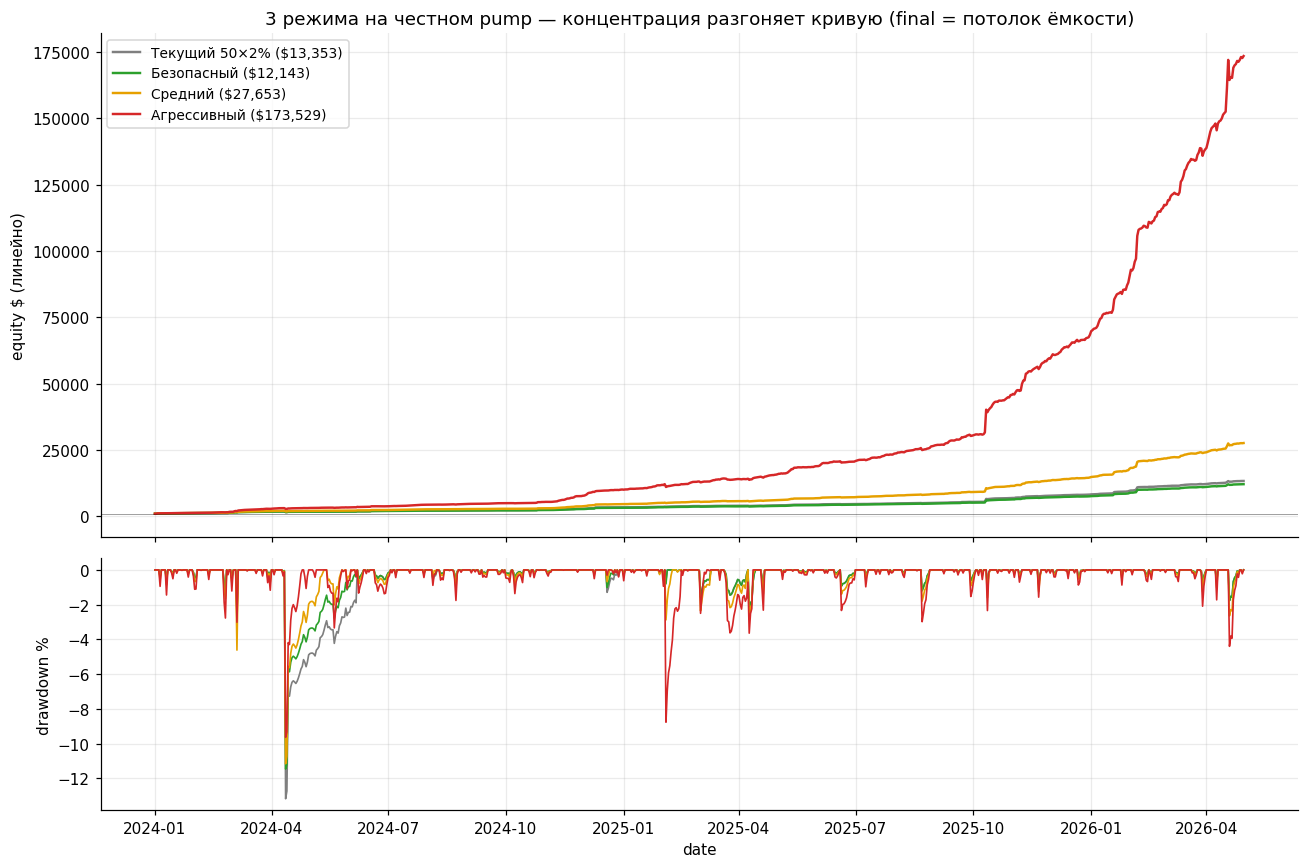

In [4]:
# ---- equity curves (LINEAR) + drawdowns ----
import matplotlib.pyplot as plt
fig,ax=plt.subplots(2,1,figsize=(12,8),sharex=True,gridspec_kw={'height_ratios':[2,1]})
col=['#7f7f7f','#2ca02c','#e6a000','#d62728']
for row,cc in zip(rows,col):
    lab=row['mode'].replace('\U0001f7e2 ','').replace('\U0001f7e1 ','').replace('\U0001f534 ','')
    ax[0].plot(row['eq'].index,row['eq'].values,lw=1.6,color=cc,label=f"{lab} (${row['final']:,.0f})")
ax[0].axhline(START,color='k',lw=.6,alpha=.4); ax[0].set_ylabel('equity $ (\u043b\u0438\u043d\u0435\u0439\u043d\u043e)')
ax[0].legend(loc='upper left',fontsize=9); ax[0].set_title('3 \u0440\u0435\u0436\u0438\u043c\u0430 \u043d\u0430 \u0447\u0435\u0441\u0442\u043d\u043e\u043c pump \u2014 \u043a\u043e\u043d\u0446\u0435\u043d\u0442\u0440\u0430\u0446\u0438\u044f \u0440\u0430\u0437\u0433\u043e\u043d\u044f\u0435\u0442 \u043a\u0440\u0438\u0432\u0443\u044e (final = \u043f\u043e\u0442\u043e\u043b\u043e\u043a \u0451\u043c\u043a\u043e\u0441\u0442\u0438)')
for row,cc in zip(rows,col):
    dd=(row['eq']/row['eq'].cummax()-1)*100
    ax[1].plot(dd.index,dd.values,lw=1.1,color=cc)
ax[1].set_ylabel('drawdown %'); ax[1].set_xlabel('date')
show('comb_05_modes')

## Итог (1:1 с ботом — pump 3%-стоп, dump без KS)

| режим | размер | maxDD | Sharpe | CAGR | final$ (потолок) | skip |
|---|---|---|---|---|---|---|
| 🟢 Безопасный | 2% +рез10 | −11.5% | 5.13 | +192% | $12k | 27% |
| 🟡 Средний | 3% +рез10 | −11.2% | 6.45 | +316% | $28k | 30% |
| 🔴 Агрессивный | 5% +рез10 | −9.6% | 7.23 | +817% | $174k | 34% |

- **Sharpe монотонно растёт с концентрацией** (5.13 → 6.45 → 7.23) — как и раньше.
- **Неожиданно: maxDD у агрессивного НИЖЕ (−9.6%), чем у безопасного (−11.5%).** Это артефакт идеального движка
  без ёмкости: меньше слотов (18 vs 45) → больше пропусков (`skip` 34% vs 27%), и пропускаются как раз
  коррелированные кластерные dump-сигналы (риск-офф бьёт все альты разом) → меньше кластерной экспозиции → ниже DD.
  **НЕ читать как «агрессивный безопаснее»:** под реальной ёмкостью (nb02/03) крупная позиция бьётся о ликвидность,
  и там агрессивный наоборот ХУЖЕ (DCA-прогон давал ~−21%). Idealized-DD здесь ненадёжен как риск-метрика.
- win/avg/PF почти не меняются (≈61% win, +1.6..1.7%/трейд, PF ~2.1) — сайзинг это **ручка громкости**.
- Резерв 10% подтверждён: `maxDep` = 90% у всех режимов с резервом (vs 100% у текущего).

**Важно:** `final$` ($174k у агрессивного) — компаунд-фантазия без ёмкости. Реальные per-mode числа риска нужно
брать из capacity/DCA модели (nb02/03), **перепрогнанной на этом честном combined** (пока не сделано). Idealized
in-sample DD-порядок обманчив (даёт агрессивный самым «безопасным»).

**Оговорки:** in-sample 2024–04.2026; идеальное исполнение (без слиппеджа/импакта); классификаторы тонкие,
train-регион без фильтра; dump без KS = выше доход, но без страховки от неучтённого каскада.